# 03 - Feature Engineering Analizi

Adım 3: temporal, entity, relational ve context feature'ları. Feature'lar `src/fraud_platform/features/` altında,
her grup bir `FeatureBuilder` sınıfı; `FeaturePipeline` hepsini sırayla çalıştırır (`scripts/prepare_data.py`).

Bu notebook: (1) leakage kararı, (2) feature sözlüğü, (3) her feature'ın fraud ile ilişkisi, (4) örnek işlem okuması.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import roc_auc_score

from fraud_platform.config import PROJECT_ROOT, get_settings
from fraud_platform.features.pipeline import FeaturePipeline

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 90)
sns.set_theme(style="whitegrid")
IMG = PROJECT_ROOT / "docs" / "images"

settings = get_settings()
TARGET, AMT = settings.data.target_column, settings.data.amount_column

pipeline = FeaturePipeline.load(settings.feature_pipeline_path)
df = pd.read_parquet(settings.features_path)
FEATS = [f for f in pipeline.feature_names if f not in ("uid", "device_key")]
BASE_RATE = df[TARGET].mean()
print(df.shape, "|", len(FEATS), "sayısal feature")

(590540, 490) | 53 sayısal feature


## 1. Leakage kararı: tüm veri mi, sadece geçmiş mi?

Entity ortalaması tüm veriden hesaplanırsa bir işlemin "geçmişi" kendisinden sonraki işlemleri de içerir.
Aşağıda aynı feature iki yolla hesaplanıp karşılaştırılıyor.

In [2]:
uid, amt = df["uid"], df[AMT]
g = amt.groupby(uid)
full_mean, full_cnt = g.transform("mean"), g.transform("size")

def auc(x):
    m = x.notna()
    a = roc_auc_score(df.loc[m, TARGET], x[m])
    return max(a, 1 - a)

pd.DataFrame({
    "tüm veri": {
        "gelecek bilgisi içeren satır": (full_cnt > df["user_tx_count"] + 1).mean(),
        "geçmişi olmayan (feature boş)": 0.0,
        "AUC amount_to_user_avg": auc(amt / full_mean),
        "AUC user_tx_count": auc(full_cnt.astype(float)),
    },
    "sadece geçmiş (seçilen)": {
        "gelecek bilgisi içeren satır": 0.0,
        "geçmişi olmayan (feature boş)": df["is_first_tx"].mean(),
        "AUC amount_to_user_avg": auc(df["amount_to_user_avg"]),
        "AUC user_tx_count": auc(df["user_tx_count"].astype(float)),
    },
}).round(4)

,tüm veri,sadece geçmiş (seçilen)
gelecek bilgisi içeren satır,0.6311,0.0000
geçmişi olmayan (feature boş),0.0000,0.3689
AUC amount_to_user_avg,0.5161,0.5145
AUC user_tx_count,0.5676,0.5601


Karar: sadece geçmiş. Sinyal kaybı ihmal edilebilir; buna karşılık eğitimdeki feature'lar API'de gerçek zamanlı
hesaplanacak feature'larla aynı mantıkta (train/serve tutarlılığı). Doğrulama: `tests/test_features.py::test_pipeline_has_no_future_leakage`.

> **Yorum:** Kullanıcı ortalamasını tüm veriden hesaplasaydım satırların %63,1'inde "geçmiş" gelecekteki işlemleri de içerecekti; model
> eğitimde, canlıda göremeyeceği bilgiyi kullanmış olurdu. Sadece geçmişle hesaplayınca AUC neredeyse hiç değişmiyor (0,516 -> 0,515
> ve 0,568 -> 0,560), yani bu sinyali sızıntıdan almıyormuşuz. Asıl kazanç tutarlılık: API'ye bir işlem geldiğinde sadece geçmişi
> görebiliyoruz, eğitimde de öyle olmalı. Bedeli işlemlerin %36,9'unun ilk işlem olması ve entity feature'larının boş kalması;
> bunu is_first_tx bayrağıyla işaretledim. Adım 6'daki en değerli context kuralı da bundan çıktı.

## 2. Feature sözlüğü

`layers` kolonu feature'ın hangi dedektör / motor tarafından kullanılacağını gösterir (Adım 4-7).

In [3]:
dictionary = pipeline.dictionary()
print(dictionary.groupby("group").size().to_string())
dictionary

group
context       18
entity        14
relational    13
temporal      10


,feature,group,builder,description,layers
0,addr1_isna,context,MissingnessFeatures,addr1 boş (boşluk fraud ile ilişkili),"multivariate, context"
1,dist1_isna,context,MissingnessFeatures,dist1 boş (boşluk fraud ile ilişkili),"multivariate, context"
2,R_emaildomain_isna,context,MissingnessFeatures,R_emaildomain boş (boşluk fraud ile ilişkili),"multivariate, context"
3,M1_isna,context,MissingnessFeatures,M1 boş (boşluk fraud ile ilişkili),"multivariate, context"
4,M4_isna,context,MissingnessFeatures,M4 boş (boşluk fraud ile ilişkili),"multivariate, context"
5,M6_isna,context,MissingnessFeatures,M6 boş (boşluk fraud ile ilişkili),"multivariate, context"
6,M7_isna,context,MissingnessFeatures,M7 boş (boşluk fraud ile ilişkili),"multivariate, context"
7,null_count,context,MissingnessFeatures,Satırdaki boş ham kolon sayısı (eksiklik profili),multivariate
8,uid,entity,EntityKeys,Sözde kullanıcı: card1 + addr1 + (işlem günü - D1),entity
9,device_key,entity,EntityKeys,Cihaz parmak izi: DeviceInfo|id_31|id_33|id_19|id_20,entity


## 3. Feature'ların fraud ile ilişkisi

In [4]:
rows = []
for f in FEATS:
    s = df[f]
    m = s.notna()
    a = roc_auc_score(df.loc[m, TARGET], s[m]) if s[m].nunique() > 1 else 0.5
    rows.append({
        "feature": f,
        "null": 1 - m.mean(),
        "ort_normal": s[df[TARGET] == 0].mean(),
        "ort_fraud": s[df[TARGET] == 1].mean(),
        "auc": max(a, 1 - a),
        "yön": "fraud'da yüksek" if a >= 0.5 else "fraud'da düşük",
    })
signal = pd.DataFrame(rows).merge(dictionary[["feature", "group"]], on="feature").set_index("feature")
signal.sort_values("auc", ascending=False).round(4)

,null,ort_normal,ort_fraud,auc,yön,group
feature,,,,,,
R_emaildomain_freq,0.0000,0.0531,0.1657,0.6750,fraud'da yüksek,relational
time_since_last_tx,0.3689,891806.4357,286908.0200,0.6744,fraud'da düşük,temporal
null_count,0.0000,196.8528,161.6978,0.6710,fraud'da düşük,context
R_emaildomain_isna,0.0000,0.7788,0.4567,0.6611,fraud'da düşük,context
email_match,0.0000,0.1625,0.4787,0.6581,fraud'da yüksek,relational
M6_isna,0.0000,0.2762,0.5793,0.6516,fraud'da yüksek,context
id_31_freq,0.0000,0.0145,0.0304,0.6497,fraud'da yüksek,relational
addr1_freq,0.0000,0.0385,0.0256,0.6486,fraud'da düşük,relational
combo_rarity,0.0000,0.9425,0.9696,0.6432,fraud'da yüksek,relational


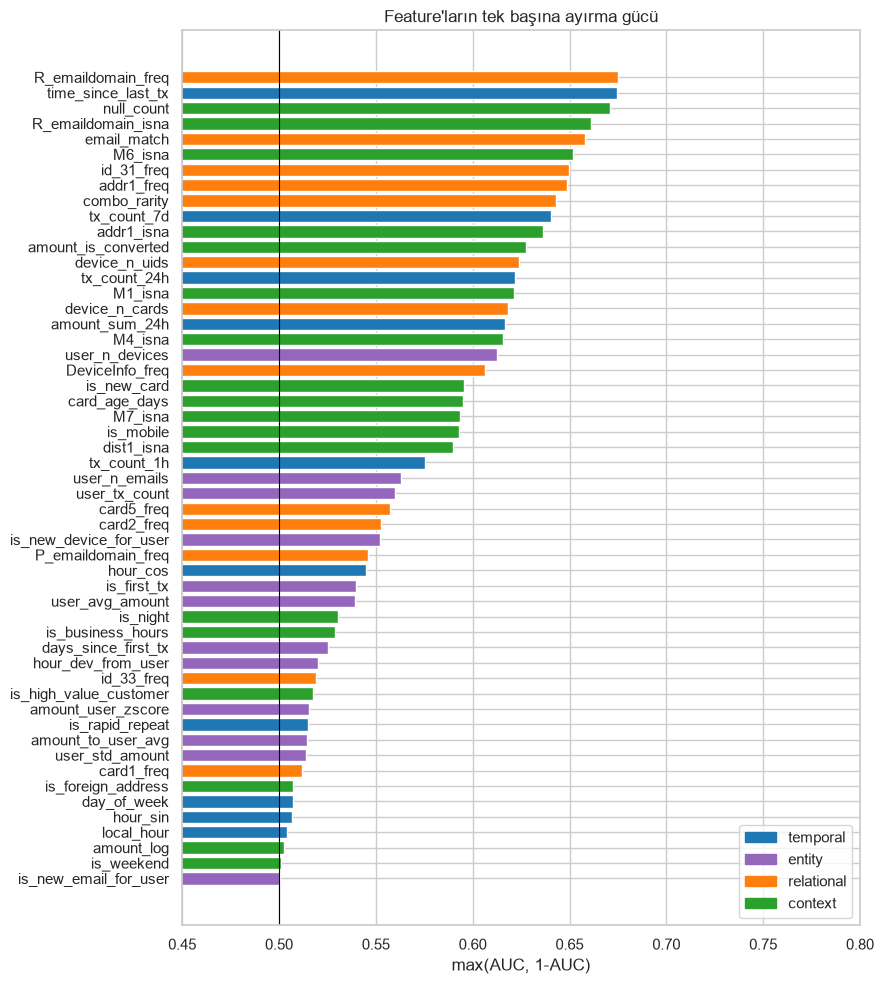

In [5]:
fig, ax = plt.subplots(figsize=(9, 10))
s = signal.sort_values("auc")
colors = s["group"].map({"temporal": "tab:blue", "entity": "tab:purple", "relational": "tab:orange", "context": "tab:green"})
ax.barh(s.index, s["auc"], color=colors)
ax.axvline(0.5, color="black", lw=0.8)
ax.set(title="Feature'ların tek başına ayırma gücü", xlabel="max(AUC, 1-AUC)", xlim=(0.45, 0.8))
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=g) for g, c in [("temporal", "tab:blue"), ("entity", "tab:purple"),
                                                         ("relational", "tab:orange"), ("context", "tab:green")]],
          loc="lower right")
plt.tight_layout()
fig.savefig(IMG / "03_feature_auc.png", dpi=120)

Bayrak (0/1) feature'lar: bayrak açıkken fraud oranı ve genel orana göre lift. Adım 6 context kurallarının ve
Adım 7 iş kurallarının sayısal dayanağı bu tablo.

In [6]:
flags = [f for f in FEATS if set(df[f].dropna().unique()) <= {0, 1}]
flag_tbl = pd.DataFrame({
    f: {
        "açık_oranı": df[f].mean(),
        "fraud_açık": df.loc[df[f] == 1, TARGET].mean(),
        "fraud_kapalı": df.loc[df[f] == 0, TARGET].mean(),
    }
    for f in flags
}).T
flag_tbl["lift"] = flag_tbl["fraud_açık"] / BASE_RATE
flag_tbl.sort_values("lift", ascending=False).round(4)

,açık_oranı,fraud_açık,fraud_kapalı,lift
addr1_isna,0.1113,0.1178,0.0246,3.3670
amount_is_converted,0.1049,0.1172,0.0254,3.3497
is_foreign_address,0.0074,0.1022,0.0345,2.9216
is_mobile,0.0942,0.1017,0.0281,2.9055
email_match,0.1736,0.0965,0.0221,2.7577
is_rapid_repeat,0.0175,0.0926,0.0340,2.6453
is_new_device_for_user,0.0761,0.0812,0.0312,2.3220
is_night,0.0476,0.0782,0.0328,2.2358
M6_isna,0.2868,0.0707,0.0206,2.0201
is_high_value_customer,0.0631,0.0536,0.0337,1.5322


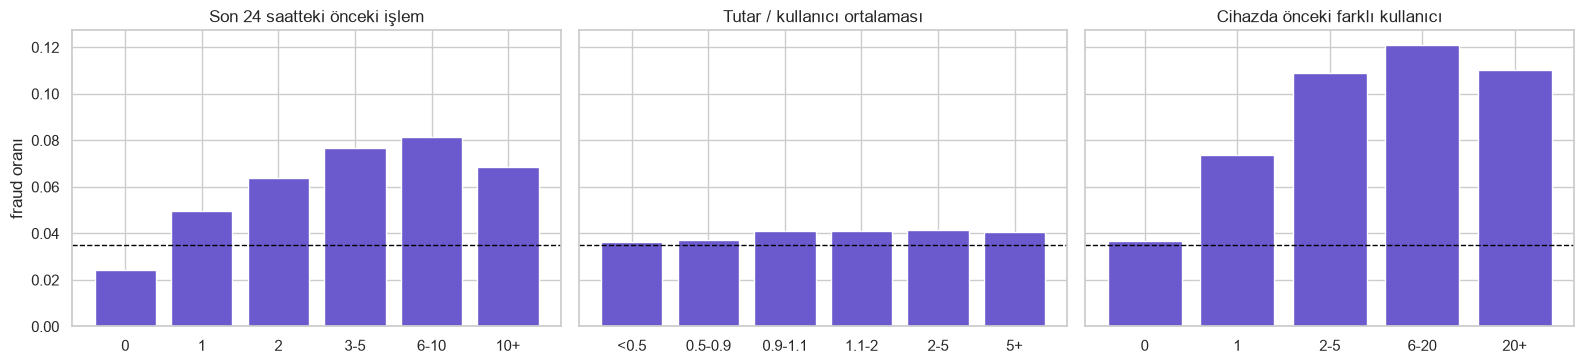

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 3.8), sharey=True)
panels = [
    ("tx_count_24h", [-1, 0, 1, 2, 5, 10, np.inf], ["0", "1", "2", "3-5", "6-10", "10+"], "Son 24 saatteki önceki işlem"),
    ("amount_to_user_avg", [0, 0.5, 0.9, 1.1, 2, 5, np.inf], ["<0.5", "0.5-0.9", "0.9-1.1", "1.1-2", "2-5", "5+"], "Tutar / kullanıcı ortalaması"),
    ("device_n_uids", [-1, 0, 1, 5, 20, np.inf], ["0", "1", "2-5", "6-20", "20+"], "Cihazda önceki farklı kullanıcı"),
]
for ax, (col, bins, labels, title) in zip(axes, panels):
    b = pd.cut(df[col], bins, labels=labels)
    r = df.groupby(b, observed=True)[TARGET].mean()
    ax.bar(r.index.astype(object).astype(str), r.values, color="slateblue")
    ax.axhline(BASE_RATE, color="black", ls="--", lw=1)
    ax.set(title=title)
axes[0].set_ylabel("fraud oranı")
plt.tight_layout()
fig.savefig(IMG / "03_feature_bins.png", dpi=120)

> **Yorum:** Tek başına en güçlü feature'lar AUC 0,64-0,68 arasında: karşı tarafın e-posta domaininin sıklığı (R_emaildomain_freq 0,675),
> önceki işlemden geçen süre (0,674; fraud'da ortalama 3,3 gün, normalde 10,3 gün), satırdaki boş kolon sayısı (0,671; fraud
> işlemlerde daha az boş, çünkü identity'li işlemler daha riskli) ve iki e-postanın aynı olması (0,658). Bayraklarda adres boş
> (3,4 kat), kur çevrimi izi (3,3), yurt dışı adres (2,9), mobil (2,9) ve 60 sn içinde tekrar (2,6) öne çıkıyor. Velocity monoton
> artıyor: son 24 saatte önceki işlem yoksa fraud %2,4, 6-10 işlem varsa %8,2; cihazda daha önce 6-20 farklı kullanıcı
> görülmüşse %12. Beklediğim bazı sinyaller çıkmadı: tutar / kullanıcı ortalaması her aralıkta ~%4, hafta sonu ve yeni e-posta
> etkisiz. Hiçbir feature tek başına yeterli değil; katmanlı yaklaşımın gerekçesi bu.

## 4. Örnek işlem okuması

Bir feature satırı "skor 0,87" yerine okunabilir bir gerekçeye dönüşebilmeli (Adım 7 açıklamaları buradan beslenecek).

In [8]:
cand = df[(df[TARGET] == 1) & (df["user_tx_count"] >= 3) & (df["amount_to_user_avg"] > 5)]
row = cand.iloc[0]
print(f"TransactionID {row['TransactionID']}  (isFraud={row[TARGET]})")
print(f"- tutar {row[AMT]:.2f} USD, kullanıcının geçmiş ortalaması {row['user_avg_amount']:.2f} -> {row['amount_to_user_avg']:.1f} katı")
print(f"- kullanıcının önceki işlem sayısı {row['user_tx_count']}, son 24 saatte {row['tx_count_24h']} işlem")
print(f"- yerel saat {row['local_hour']}:00, kullanıcının alışık saatinden {row['hour_dev_from_user']:.1f} saat sapma")
print(f"- yeni cihaz: {bool(row['is_new_device_for_user'])}, cihazda önceki farklı kullanıcı: {row['device_n_uids']}")
print(f"- gece: {bool(row['is_night'])}, yabancı adres: {bool(row['is_foreign_address'])}, kur çevrimi izi: {bool(row['amount_is_converted'])}")

TransactionID 2989544  (isFraud=1)
- tutar 632.00 USD, kullanıcının geçmiş ortalaması 89.13 -> 7.1 katı
- kullanıcının önceki işlem sayısı 10, son 24 saatte 10 işlem
- yerel saat 11:00, kullanıcının alışık saatinden 4.0 saat sapma
- yeni cihaz: False, cihazda önceki farklı kullanıcı: nan
- gece: False, yabancı adres: False, kur çevrimi izi: False


## 5. Özet

Üretilen çıktılar: `data/processed/features.parquet`, `artifacts/feature_pipeline.joblib` (fit edilmiş frekans tabloları ve eşikler),
`artifacts/feature_dictionary.csv`, `docs/images/03_*.png`

- En güçlü: e-posta domain sıklığı ve eşleşmesi, önceki işlemden geçen süre, eksiklik profili, velocity ve cihaz paylaşımı.
- Ters çıkan: yüksek değerli müşteri daha riskli (1,53), ilk işlem daha az riskli (0,79), iş saati biraz daha güvenli (0,91). Adım 6'da context kurallarını bu ölçümlere göre kurdum.
- Çürüyen varsayımlar: yabancı e-posta uzantısı, kişisel tutar sapması, hafta sonu, yeni e-posta.
- Düzelttiğim hata: "3 ondalık hane" oranı float hatası yüzünden %12,5 çıkmıştı, doğrusu %10,5.
- Sınırlamalar: uid C/H/R ürünlerinde parçalanıyor; saat dilimi ve referans tarih varsayım; frekans tabloları eğitim verisinden, zamanla güncellenmeli.